In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('petrochemical_maintenance.csv')
df.head()

,timestamp,equipment_id,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
0,2025-08-12 10:00:21.509191,EQ-002,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault,0
1,2025-08-12 10:00:31.509191,EQ-005,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault,0
2,2025-08-12 10:00:41.509191,EQ-003,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault,1
3,2025-08-12 10:00:51.509191,EQ-009,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault,0
4,2025-08-12 10:01:01.509191,EQ-007,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault,0


In [3]:
df.shape

(5000, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             5000 non-null   object 
 1   equipment_id          5000 non-null   object 
 2   vibration_x           5000 non-null   float64
 3   vibration_y           5000 non-null   float64
 4   vibration_z           5000 non-null   float64
 5   temperature_c         5000 non-null   float64
 6   current_a             5000 non-null   float64
 7   rpm                   5000 non-null   float64
 8   pressure_bar          5000 non-null   float64
 9   wavelet_feature_1     5000 non-null   float64
 10  wavelet_feature_2     5000 non-null   float64
 11  wavelet_feature_3     5000 non-null   float64
 12  wavelet_feature_4     5000 non-null   float64
 13  wavelet_feature_5     5000 non-null   float64
 14  fault_type            5000 non-null   object 
 15  maintenance_required 

In [5]:
df.isnull().sum()

timestamp               0
equipment_id            0
vibration_x             0
vibration_y             0
vibration_z             0
temperature_c           0
current_a               0
rpm                     0
pressure_bar            0
wavelet_feature_1       0
wavelet_feature_2       0
wavelet_feature_3       0
wavelet_feature_4       0
wavelet_feature_5       0
fault_type              0
maintenance_required    0
dtype: int64

In [6]:
df.describe()

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,maintenance_required
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.062282,0.062142,0.061776,76.001068,11.950740,2920.493629,5.417371,-0.017568,-0.005989,-0.010578,0.021800,0.000263,0.395800
std,0.087444,0.086996,0.086654,9.396747,2.799776,120.699363,0.773510,0.995384,1.006752,1.003449,1.014089,1.005985,0.489071
min,-0.074409,-0.079232,-0.074427,53.406406,6.752987,2522.785379,3.345714,-3.841926,-3.708700,-3.468916,-3.421746,-3.403457,0.000000
25%,-0.004813,-0.003731,-0.004573,68.869254,9.782357,2834.785840,4.863258,-0.685239,-0.680994,-0.692082,-0.669576,-0.673880,0.000000
50%,0.018631,0.018196,0.019047,74.060406,10.891146,2958.352272,5.315433,-0.005531,-0.019370,-0.016875,0.023731,-0.023749,0.000000
75%,0.132800,0.130318,0.132723,82.822620,14.257743,3010.739975,5.896007,0.652951,0.679174,0.657735,0.713676,0.675060,1.000000
max,0.373233,0.365274,0.363575,110.790521,20.748306,3161.131235,8.366381,3.313657,3.394122,3.475239,3.623171,3.461276,1.000000


In [7]:
df.sample(5)

,timestamp,equipment_id,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
2908,2025-08-12 18:05:01.509191,EQ-009,0.025687,0.096821,0.099252,85.940170,14.765861,2705.248957,7.171083,0.131650,2.191892,-0.784813,-0.312874,-1.683994,misalignment,1
4874,2025-08-12 23:32:41.509191,EQ-006,0.114255,0.111652,0.113745,87.299796,14.673970,2870.467286,5.597341,0.635496,-0.377218,0.213262,-0.059602,-1.004236,misalignment,1
1230,2025-08-12 13:25:21.509191,EQ-005,0.002593,-0.012382,0.030054,72.125444,8.507436,2927.840986,4.498917,-0.255777,-1.578817,0.273384,-0.256643,-0.657537,no_fault,0
1525,2025-08-12 14:14:31.509191,EQ-005,0.013920,0.000669,0.015063,74.226139,11.142299,2981.002663,4.258420,2.642579,-0.300441,-1.484879,0.321990,-0.134097,no_fault,0
470,2025-08-12 11:18:41.509191,EQ-009,0.031608,-0.060589,-0.012781,74.855790,8.298006,2947.552899,5.629587,-1.987058,-2.026734,0.840045,1.623617,1.433204,no_fault,0


In [8]:
df.dtypes

timestamp                object
equipment_id             object
vibration_x             float64
vibration_y             float64
vibration_z             float64
temperature_c           float64
current_a               float64
rpm                     float64
pressure_bar            float64
wavelet_feature_1       float64
wavelet_feature_2       float64
wavelet_feature_3       float64
wavelet_feature_4       float64
wavelet_feature_5       float64
fault_type               object
maintenance_required      int64
dtype: object

In [9]:
# maintenance_required = 1 whenever fault_type != normal
def validate_targets(df):

    issue1 = df[
        (df['fault_type'] == 'no_fault') &
        (df['maintenance_required'] == 1)
    ]

    issue2 = df[
        (df['fault_type'] != 'no_fault') &
        (df['maintenance_required'] == 0)
    ]

    print("Issue 1:")
    print(f"Rows found: {len(issue1)}")

    print("\nIssue 2:")
    print(f"Rows found: {len(issue2)}")

    if len(issue1) == 0 and len(issue2) == 0:
        print("\n✅ No inconsistencies found.")

In [10]:
validate_targets(df)

Issue 1:
Rows found: 0

Issue 2:
Rows found: 0

✅ No inconsistencies found.


In [11]:
df.duplicated().sum()

0

In [12]:
df.nunique()

timestamp               5000
equipment_id              10
vibration_x             5000
vibration_y             5000
vibration_z             5000
temperature_c           5000
current_a               5000
rpm                     5000
pressure_bar            5000
wavelet_feature_1       5000
wavelet_feature_2       5000
wavelet_feature_3       5000
wavelet_feature_4       5000
wavelet_feature_5       5000
fault_type                 4
maintenance_required       2
dtype: int64

In [13]:
df['fault_type'].value_counts()

fault_type
no_fault           3021
bearing_fault       755
rotor_imbalance     733
misalignment        491
Name: count, dtype: int64

In [14]:
df['maintenance_required'].value_counts()

maintenance_required
0    3021
1    1979
Name: count, dtype: int64

In [15]:
def detect_hidden_nulls_summary(df):

    null_like_values = [
        'null', 'NULL',
        'na', 'NA',
        'n/a', 'N/A',
        '',
        ' '
    ]

    for col in df.columns:

        temp_col = df[col].astype(str).str.strip()

        mask = temp_col.isin(null_like_values)

        count = mask.sum()

        if count > 0:
            print(f"\nColumn: {col}")
            print(f"Hidden nulls found: {count}")

            print("Sample rows:")
            print(df.loc[mask, [col]].head())
        else:
            print("No null found")

In [16]:
detect_hidden_nulls_summary(df)

No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found
No null found


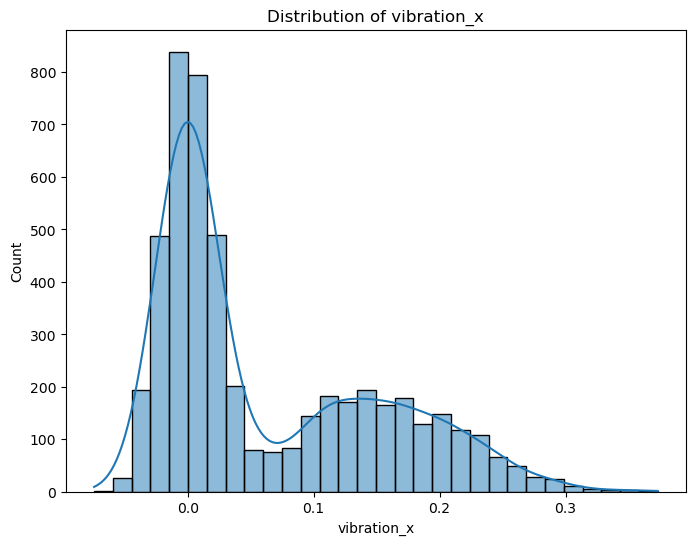

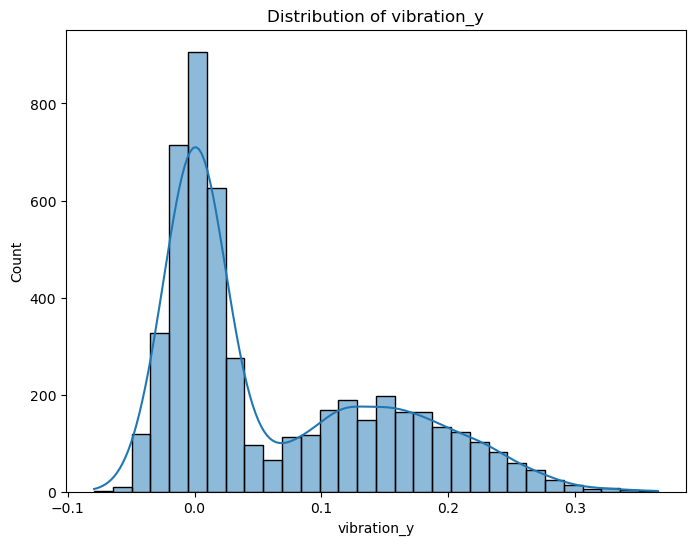

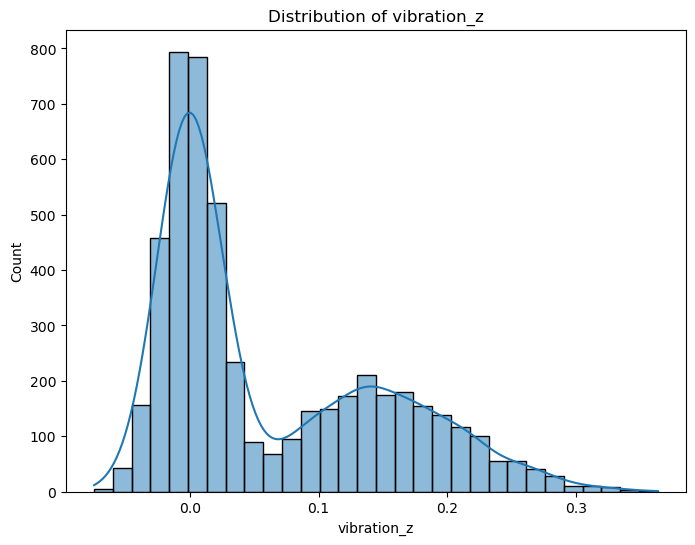

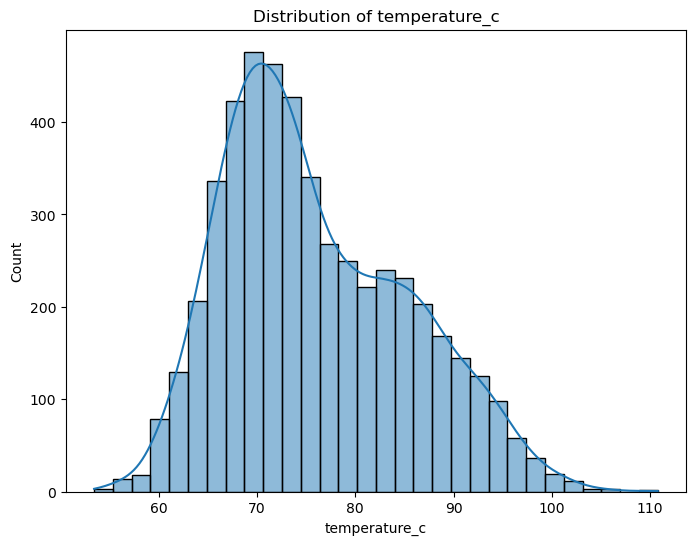

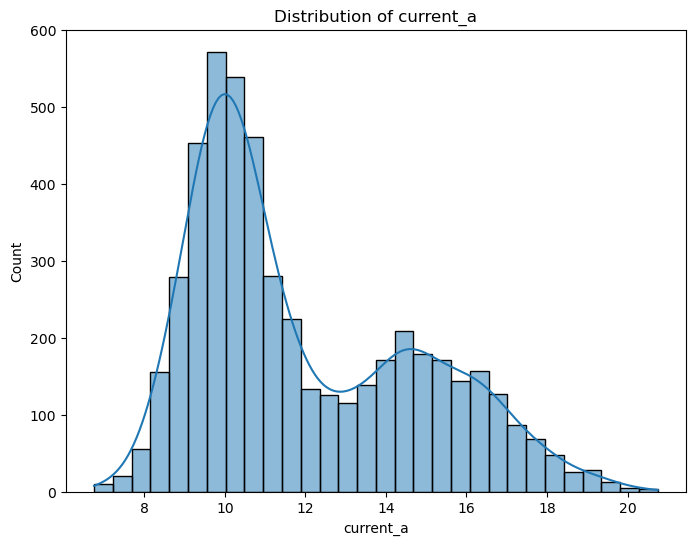

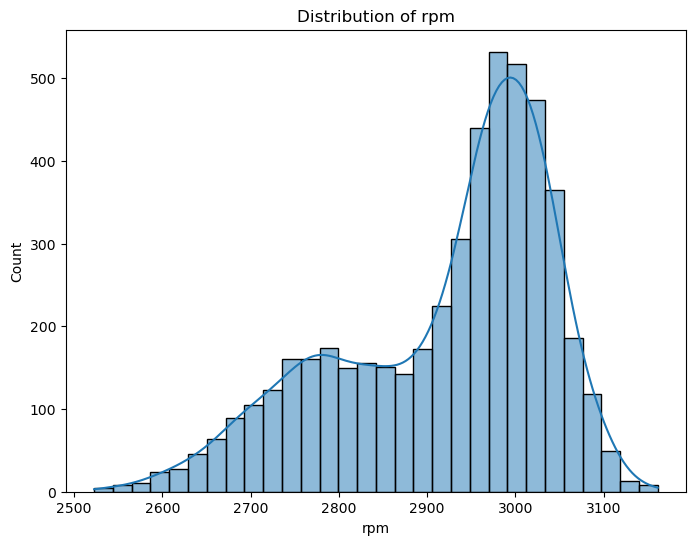

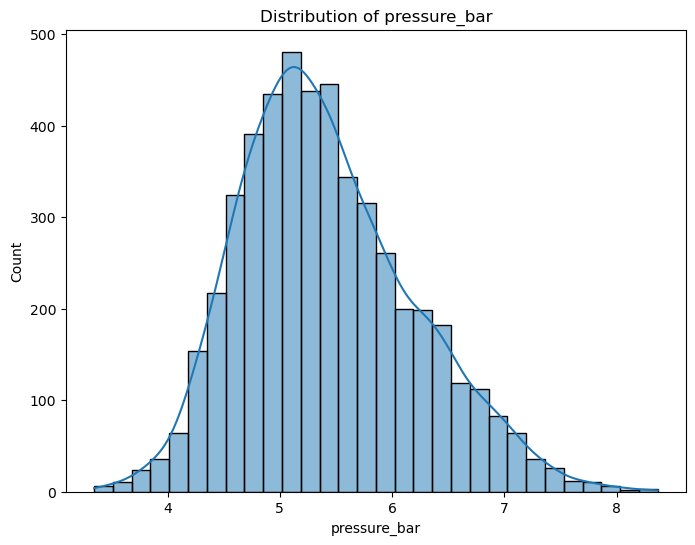

In [17]:
cols_to_check_distribution = ['vibration_x', 'vibration_y', 'vibration_z', 'temperature_c', 'current_a', 'rpm', 'pressure_bar']
for col in cols_to_check_distribution:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')

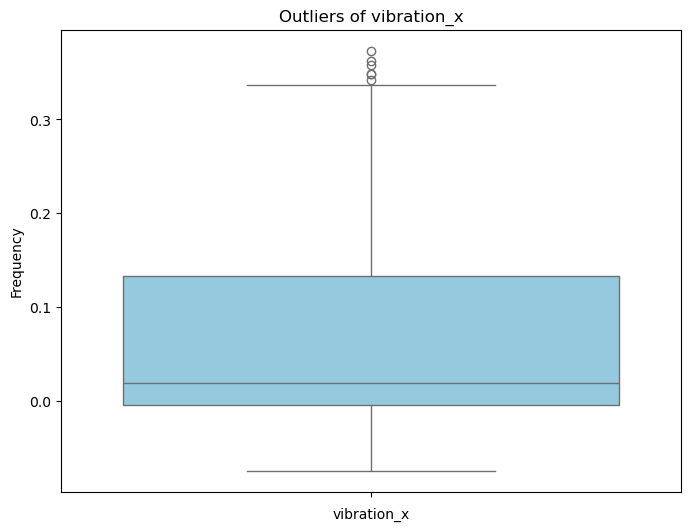

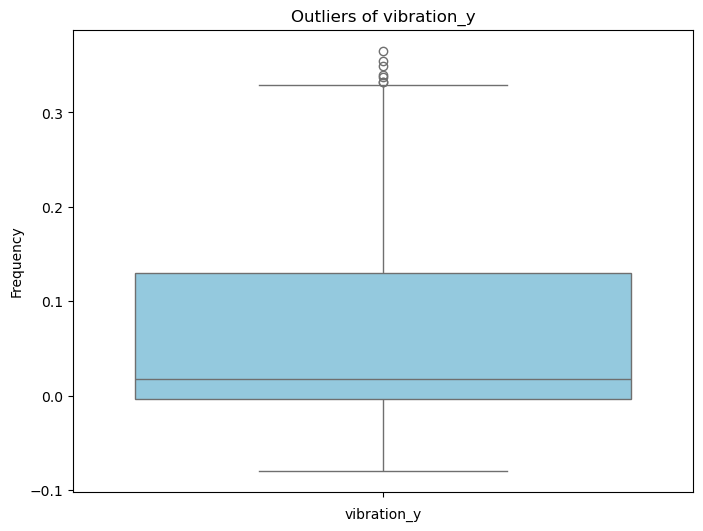

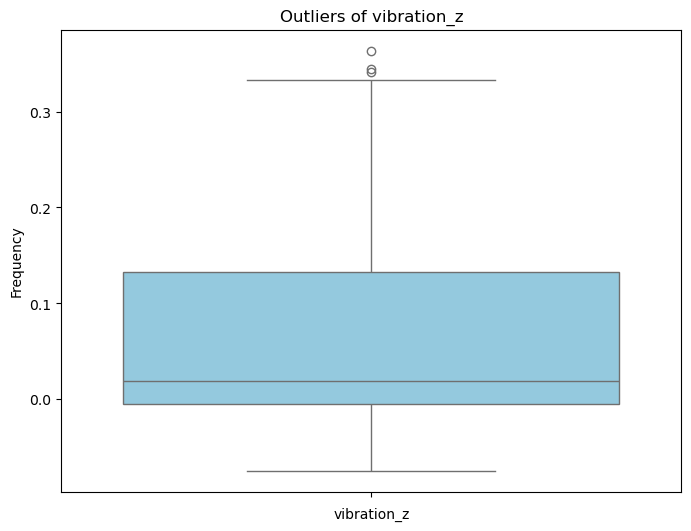

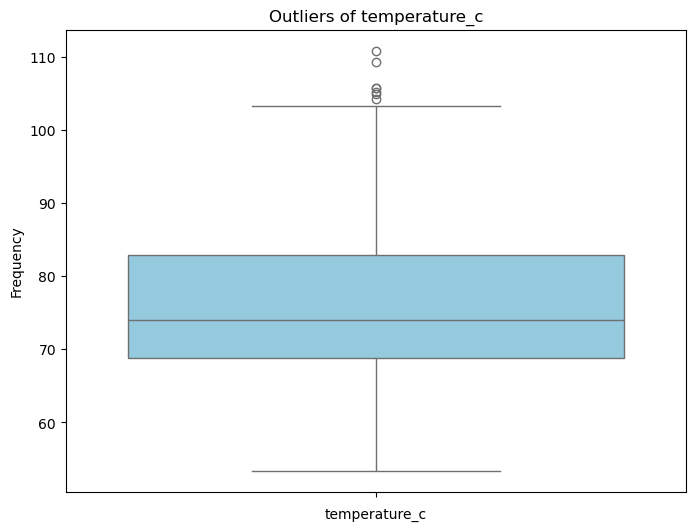

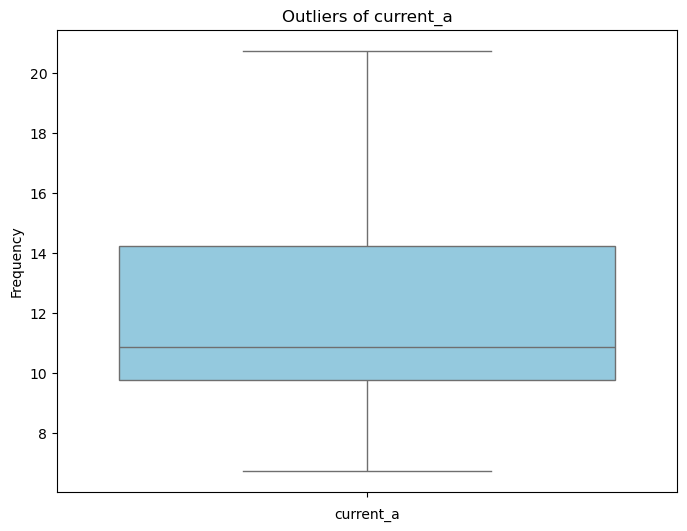

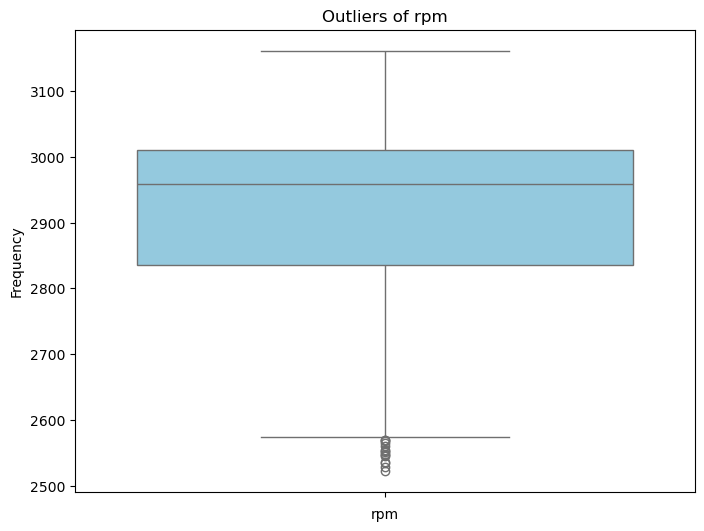

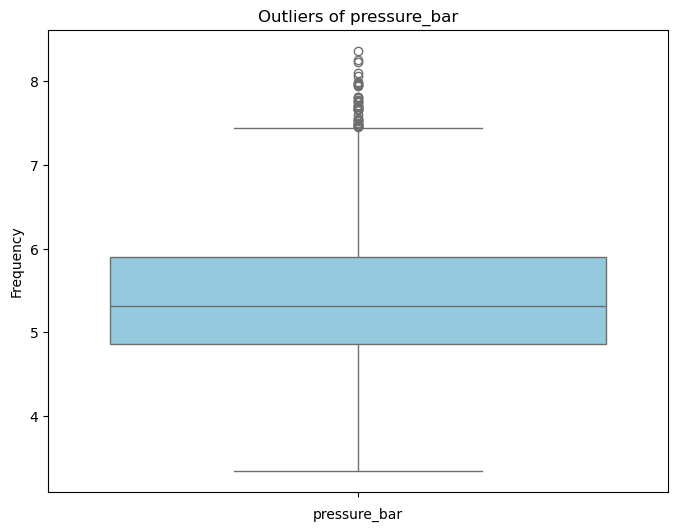

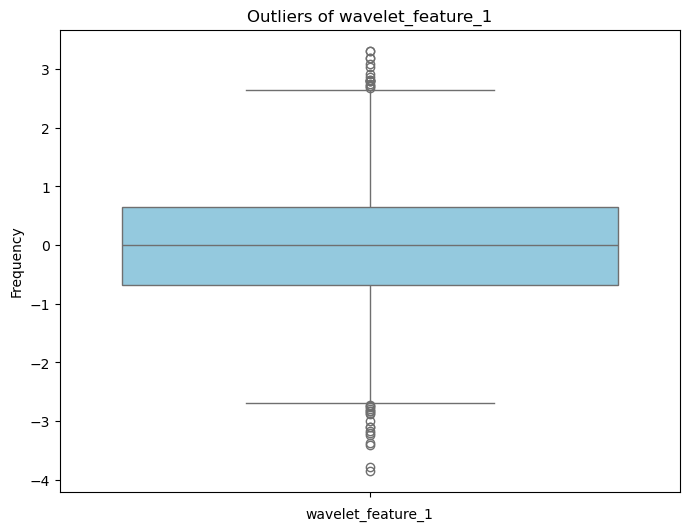

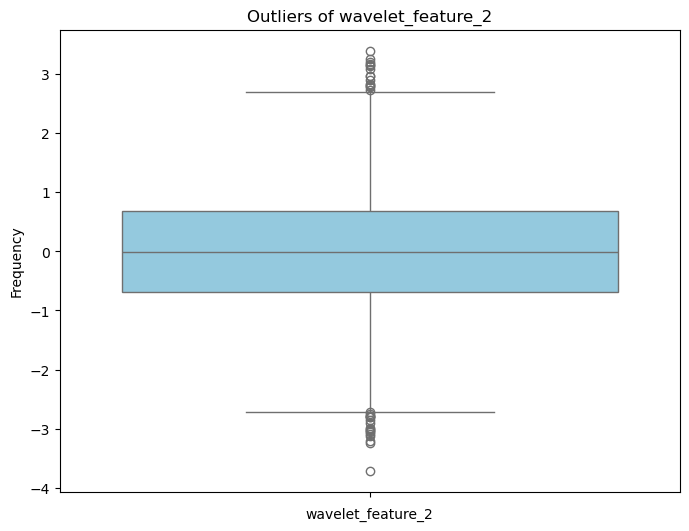

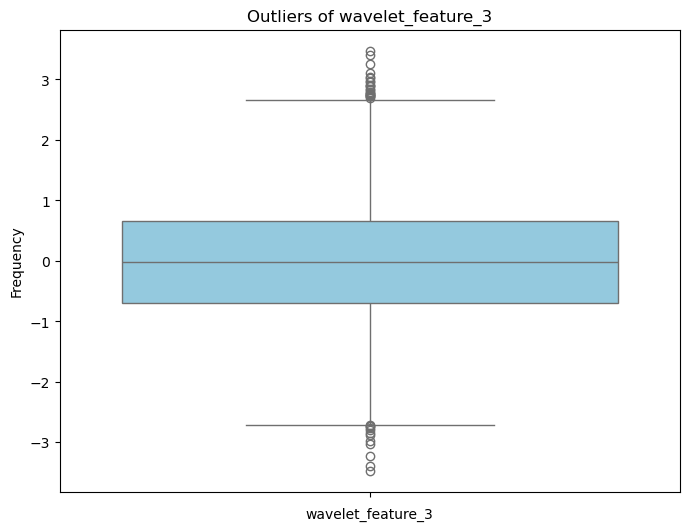

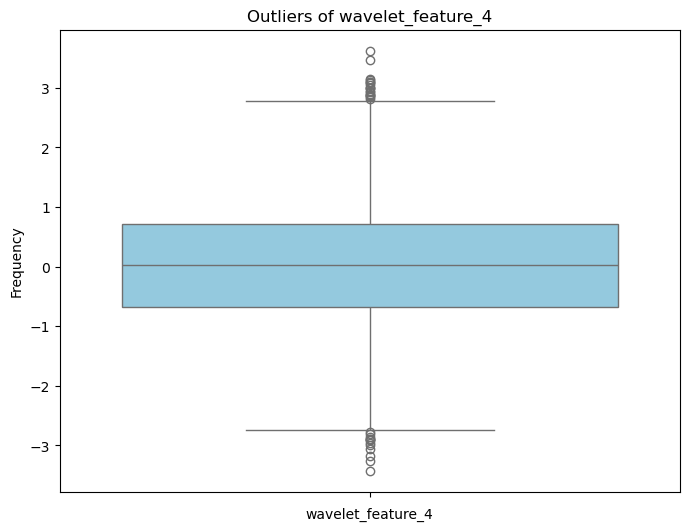

In [18]:
cols_to_check_outliers = ['vibration_x', 'vibration_y', 'vibration_z', 'temperature_c', 'current_a', 'rpm', 'pressure_bar', 'wavelet_feature_1'
                         ,'wavelet_feature_2', 'wavelet_feature_3', 'wavelet_feature_4']

for col in cols_to_check_outliers:
    plt.figure(figsize=(8, 6))
    sns.boxplot(df[col], color='skyblue')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Outliers of {col}')

<Axes: >

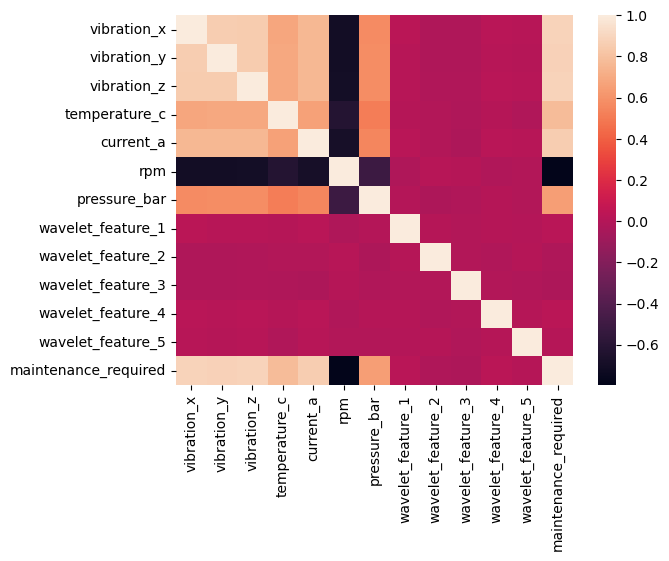

In [19]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

<Axes: xlabel='fault_type', ylabel='temperature_c'>

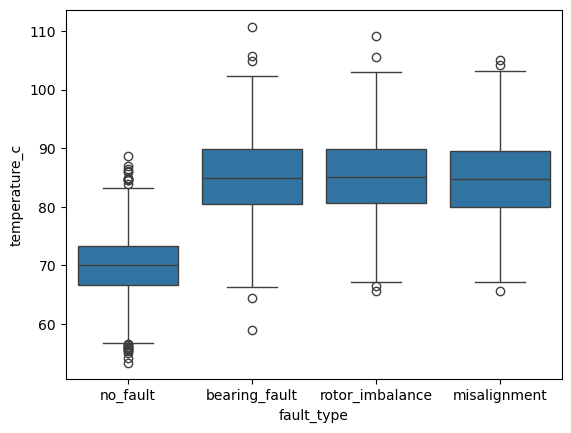

In [20]:
sns.boxplot(x='fault_type', y='temperature_c', data=df)

<Axes: xlabel='maintenance_required', ylabel='vibration_x'>

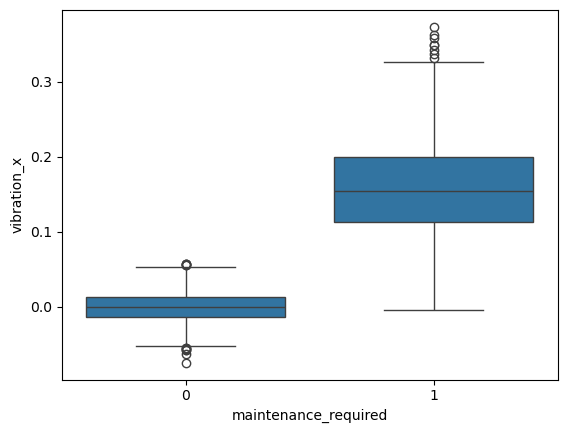

In [21]:
sns.boxplot(x='maintenance_required', y='vibration_x', data=df)

In [22]:
df.head()

,timestamp,equipment_id,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
0,2025-08-12 10:00:21.509191,EQ-002,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault,0
1,2025-08-12 10:00:31.509191,EQ-005,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault,0
2,2025-08-12 10:00:41.509191,EQ-003,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault,1
3,2025-08-12 10:00:51.509191,EQ-009,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault,0
4,2025-08-12 10:01:01.509191,EQ-007,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault,0


In [23]:
df = df.drop('timestamp', axis=1)
df = df.drop('equipment_id', axis=1)
df

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
0,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault,0
1,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault,0
2,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault,1
3,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault,0
4,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.057703,0.028558,-0.052663,71.014561,9.747689,3019.143215,4.213003,0.329242,0.703803,-0.911752,-0.108123,-0.736190,no_fault,0
4996,-0.007101,-0.004121,-0.001137,70.794923,9.809861,2994.999239,5.965899,-1.373011,-1.879467,0.821554,-0.785426,1.776213,no_fault,0
4997,0.021151,0.005132,-0.014084,68.012785,9.173987,3030.227146,4.609235,-1.388544,-1.162725,-0.426449,-0.949630,1.363981,no_fault,0
4998,-0.021202,0.003962,0.016104,76.460142,10.265523,3028.423818,5.370740,-0.130070,0.425693,-0.401792,0.925138,0.547995,no_fault,0


In [24]:
df1 = df

In [25]:
df = df.drop('maintenance_required', axis=1)

In [26]:
df.head()

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type
0,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault
1,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault
2,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault
3,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault
4,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
# Apply label encoding
le = LabelEncoder()
le

LabelEncoder()

In [29]:
df['fault_type'] = le.fit_transform(df['fault_type'])

In [30]:
df.tail()

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type
4995,0.057703,0.028558,-0.052663,71.014561,9.747689,3019.143215,4.213003,0.329242,0.703803,-0.911752,-0.108123,-0.736190,2
4996,-0.007101,-0.004121,-0.001137,70.794923,9.809861,2994.999239,5.965899,-1.373011,-1.879467,0.821554,-0.785426,1.776213,2
4997,0.021151,0.005132,-0.014084,68.012785,9.173987,3030.227146,4.609235,-1.388544,-1.162725,-0.426449,-0.949630,1.363981,2
4998,-0.021202,0.003962,0.016104,76.460142,10.265523,3028.423818,5.370740,-0.130070,0.425693,-0.401792,0.925138,0.547995,2
4999,0.194027,0.108393,0.172600,80.483804,16.527375,2823.620810,6.521823,0.367599,-0.646518,-0.483573,-0.626398,0.792143,0


In [31]:
# Train-Test Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
X = df.drop('fault_type', axis=1)
y = df['fault_type']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [34]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
rf_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, rf_pred)}")

Accuracy: 0.9016


In [36]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [37]:
xgb_pred = xgb.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred)}")

XGBoost Accuracy: 0.9024


In [39]:
models = [rf, xgb]
model_names = [ 'Random Forest', 'XGBoost']
for model, name in zip(models, model_names):
    y_pred = model.predict(X_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}\n")
    print("-" * 50)
    print()

Model: Random Forest
Accuracy: 0.9016
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       189
           1       0.78      0.79      0.79       123
           2       1.00      1.00      1.00       755
           3       0.67      0.64      0.66       183

    accuracy                           0.90      1250
   macro avg       0.81      0.82      0.82      1250
weighted avg       0.90      0.90      0.90      1250

Confusion Matrix:
[[157   1   0  31]
 [  0  97   0  26]
 [  0   0 755   0]
 [ 39  26   0 118]]

--------------------------------------------------

Model: XGBoost
Accuracy: 0.9024
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       189
           1       0.79      0.85      0.82       123
           2       1.00      1.00      1.00       755
           3       0.68      0.63      0.65       183

    accuracy                 

In [38]:
df1.head()

,vibration_x,vibration_y,vibration_z,temperature_c,current_a,rpm,pressure_bar,wavelet_feature_1,wavelet_feature_2,wavelet_feature_3,wavelet_feature_4,wavelet_feature_5,fault_type,maintenance_required
0,-0.001014,0.005853,-0.009354,74.260267,10.130073,2972.856137,4.828486,1.142983,-0.657425,0.419990,0.477962,-1.075043,no_fault,0
1,-0.028933,-0.006458,0.016110,62.646420,9.127524,3033.625211,4.465692,1.022921,2.650931,-0.815444,1.472578,0.327915,no_fault,0
2,0.243668,0.349136,0.202759,88.868460,12.769256,2753.482665,5.942975,0.211604,-2.128811,1.548664,0.634099,0.516687,bearing_fault,1
3,0.040973,0.032422,-0.003027,67.151677,10.622962,3077.578082,4.925685,0.889331,1.706350,0.988230,-1.594953,-1.194773,no_fault,0
4,0.039661,0.002196,0.006602,72.840428,11.431961,2960.856782,4.793623,-1.005365,-2.064017,0.410040,-0.865833,0.962551,no_fault,0


In [40]:
df1 = df1.drop('fault_type', axis=1)

In [42]:
X1 = df1.drop('maintenance_required', axis=1)
y1 = df1['maintenance_required']

In [43]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.25, random_state=42, stratify=y1
)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scaling
scaler = StandardScaler()

X1_train_scaled = scaler.fit_transform(X_train)
X1_test_scaled = scaler.transform(X_test)

# model
model = LogisticRegression(max_iter=500)

model.fit(X1_train_scaled, y1_train)

# prediction
y1_pred = model.predict(X1_test_scaled)

# evaluation
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print(classification_report(y1_test, y1_pred))

Accuracy: 0.6032
              precision    recall  f1-score   support

           0       0.60      1.00      0.75       755
           1       0.00      0.00      0.00       495

    accuracy                           0.60      1250
   macro avg       0.30      0.50      0.38      1250
weighted avg       0.36      0.60      0.45      1250



In [48]:
rf1 = RandomForestClassifier()
rf1.fit(X1_train, y1_train)
rf1_pred = rf1.predict(X1_test)
print(f"Accuracy for maintinance required: {accuracy_score(y1_test, rf1_pred)}")
print(classification_report(y1_test, rf1_pred))

Accuracy for maintinance required: 0.9992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       755
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



In [49]:
xgb1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb1.fit(X1_train, y1_train)
xgb1_pred = xgb1.predict(X1_test)
print(f"XGBoost Accuracy for maintinance required: {accuracy_score(y1_test, xgb1_pred)}")
print(classification_report(y1_test, xgb1_pred))

XGBoost Accuracy for maintinance required: 0.9992
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       755
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



In [54]:
models1 = [ rf1, xgb1]
model_names1 = ['Random Forest', 'XGBoost']
for model1, name in zip(models1, model_names1):
    y1_pred = model1.predict(X1_test)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y1_test, y1_pred)}")
    print(f"Classification Report:\n{classification_report(y1_test, y1_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y1_test, y1_pred)}\n")
    print("-" * 50)
    print()

Model: Random Forest
Accuracy: 0.9992
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       755
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250

Confusion Matrix:
[[754   1]
 [  0 495]]

--------------------------------------------------

Model: XGBoost
Accuracy: 0.9992
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       755
           1       1.00      1.00      1.00       495

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250

Confusion Matrix:
[[754   1]
 [  0 495]]

--------------------------------------------------

